# Understanding Regression Diagnostic Plots

This family of diagnostic plots for **linear regression models** goes beyond the 6-Plot to include plots that specifically diagnose the quality of the regression fit as a function of individual predictors.

| Plot | What it diagnoses |
|---|---|
| **Residuals vs Fitted** | Homoscedasticity, non-linearity |
| **Normal Q-Q of Residuals** | Normality of residuals |
| **Scale-Location** | Spread-level relationship (heteroscedasticity) |
| **Residuals vs Leverage** | Influential points (Cook's distance) |
| **Mean Plot** | Whether the mean response is stable at each predictor level |
| **SD Plot** | Whether the variance is stable at each predictor level |
| **Linear Correlation Plot** | Partial correlation at each predictor level |
| **Residual SD Plot** | Whether residual SD is stable across predictor range |

These correspond closely to the R `plot(lm_model)` four-panel output, plus block-design diagnostics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

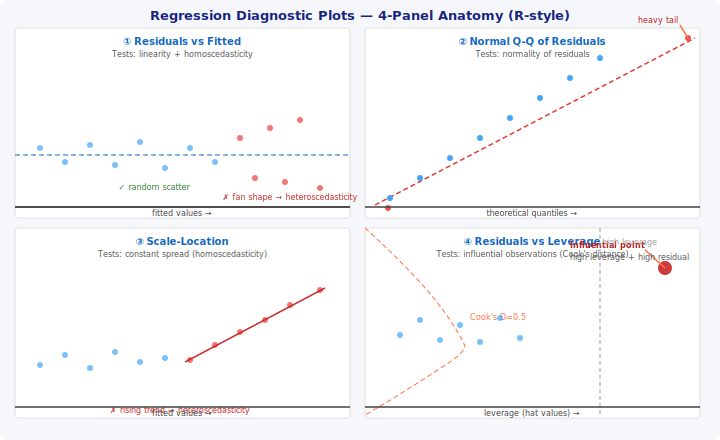

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="440"
     font-family="'Segoe UI', Arial, sans-serif">
  <rect width="720" height="440" fill="#F5F7FA" rx="8"/>
  <text x="360" y="20" text-anchor="middle" font-size="13" font-weight="bold"
        fill="#1A237E">Regression Diagnostic Plots — 4-Panel Anatomy (R-style)</text>

  <!-- ── PANEL 1: Residuals vs Fitted ── -->
  <rect x="15" y="28" width="335" height="190" fill="white" stroke="#E0E0E0" rx="3"/>
  <text x="182" y="45" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">① Residuals vs Fitted</text>
  <text x="182" y="57" text-anchor="middle" font-size="8" fill="#555">Tests: linearity + homoscedasticity</text>
  <!-- Reference line at 0 -->
  <line x1="15" y1="155" x2="350" y2="155" stroke="#1565C0" stroke-width="1" stroke-dasharray="5,3"/>
  <!-- Good: random scatter around 0 -->
  <circle cx="40"  cy="148" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="65"  cy="162" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="90"  cy="145" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="115" cy="165" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="140" cy="142" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="165" cy="168" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="190" cy="148" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="215" cy="162" r="3" fill="#42A5F5" opacity="0.7"/>
  <!-- Bad: fan shape (red) -->
  <circle cx="240" cy="138" r="3" fill="#EF5350" opacity="0.8"/>
  <circle cx="255" cy="178" r="3" fill="#EF5350" opacity="0.8"/>
  <circle cx="270" cy="128" r="3" fill="#EF5350" opacity="0.8"/>
  <circle cx="285" cy="182" r="3" fill="#EF5350" opacity="0.8"/>
  <circle cx="300" cy="120" r="3" fill="#EF5350" opacity="0.8"/>
  <circle cx="320" cy="188" r="3" fill="#EF5350" opacity="0.8"/>
  <!-- Good label -->
  <text x="155" y="190" text-anchor="middle" font-size="8" fill="#2E7D32">✓ random scatter</text>
  <!-- Bad label -->
  <text x="290" y="200" text-anchor="middle" font-size="8" fill="#C62828">✗ fan shape → heteroscedasticity</text>
  <line x1="15"  y1="207" x2="350" y2="207" stroke="#424242" stroke-width="1.5"/>
  <text x="182" y="216" text-anchor="middle" font-size="8" fill="#424242">fitted values →</text>

  <!-- ── PANEL 2: Normal Q-Q ── -->
  <rect x="365" y="28" width="335" height="190" fill="white" stroke="#E0E0E0" rx="3"/>
  <text x="532" y="45" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">② Normal Q-Q of Residuals</text>
  <text x="532" y="57" text-anchor="middle" font-size="8" fill="#555">Tests: normality of residuals</text>
  <!-- Diagonal reference -->
  <line x1="375" y1="205" x2="695" y2="38" stroke="#E53935" stroke-width="1.5" stroke-dasharray="5,3"/>
  <!-- Good points on diagonal -->
  <circle cx="390" cy="198" r="3" fill="#42A5F5"/>
  <circle cx="420" cy="178" r="3" fill="#42A5F5"/>
  <circle cx="450" cy="158" r="3" fill="#42A5F5"/>
  <circle cx="480" cy="138" r="3" fill="#42A5F5"/>
  <circle cx="510" cy="118" r="3" fill="#42A5F5"/>
  <circle cx="540" cy="98"  r="3" fill="#42A5F5"/>
  <circle cx="570" cy="78"  r="3" fill="#42A5F5"/>
  <circle cx="600" cy="58"  r="3" fill="#42A5F5"/>
  <!-- Heavy tail (red, deviates at extremes) -->
  <circle cx="388" cy="208" r="3" fill="#EF5350"/>
  <circle cx="688" cy="38"  r="3" fill="#EF5350"/>
  <line x1="688" y1="38" x2="680" y2="25" stroke="#FF7043" stroke-width="1.5"/>
  <text x="678" y="23" text-anchor="end" font-size="8" fill="#B71C1C">heavy tail</text>
  <line x1="15"  y1="207" x2="350" y2="207" stroke="#424242" stroke-width="1.5"/>
  <line x1="365" y1="207" x2="700" y2="207" stroke="#424242" stroke-width="1.5"/>
  <text x="532" y="216" text-anchor="middle" font-size="8" fill="#424242">theoretical quantiles →</text>

  <!-- ── PANEL 3: Scale-Location ── -->
  <rect x="15" y="228" width="335" height="190" fill="white" stroke="#E0E0E0" rx="3"/>
  <text x="182" y="245" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">③ Scale-Location</text>
  <text x="182" y="257" text-anchor="middle" font-size="8" fill="#555">Tests: constant spread (homoscedasticity)</text>
  <!-- Good: flat trend -->
  <circle cx="40"  cy="365" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="65"  cy="355" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="90"  cy="368" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="115" cy="352" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="140" cy="362" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="165" cy="358" r="3" fill="#42A5F5" opacity="0.7"/>
  <!-- Upward trend (red) -->
  <circle cx="190" cy="360" r="3" fill="#EF5350" opacity="0.8"/>
  <circle cx="215" cy="345" r="3" fill="#EF5350" opacity="0.8"/>
  <circle cx="240" cy="332" r="3" fill="#EF5350" opacity="0.8"/>
  <circle cx="265" cy="320" r="3" fill="#EF5350" opacity="0.8"/>
  <circle cx="290" cy="305" r="3" fill="#EF5350" opacity="0.8"/>
  <circle cx="320" cy="290" r="3" fill="#EF5350" opacity="0.8"/>
  <!-- Trend line -->
  <line x1="185" y1="362" x2="325" y2="288" stroke="#C62828" stroke-width="1.5"/>
  <text x="180" y="413" text-anchor="middle" font-size="8" fill="#C62828">✗ rising trend → heteroscedasticity</text>
  <line x1="15"  y1="407" x2="350" y2="407" stroke="#424242" stroke-width="1.5"/>
  <text x="182" y="416" text-anchor="middle" font-size="8" fill="#424242">fitted values →</text>

  <!-- ── PANEL 4: Residuals vs Leverage ── -->
  <rect x="365" y="228" width="335" height="190" fill="white" stroke="#E0E0E0" rx="3"/>
  <text x="532" y="245" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">④ Residuals vs Leverage</text>
  <text x="532" y="257" text-anchor="middle" font-size="8" fill="#555">Tests: influential observations (Cook's distance)</text>
  <!-- Cook's distance contour lines -->
  <path d="M 365,228 C 400,260 430,290 450,320 C 460,335 465,345 465,347 C 465,349 460,355 450,362 C 430,375 400,395 365,415"
        fill="none" stroke="#FF7043" stroke-width="1" stroke-dasharray="5,3"/>
  <text x="470" y="320" font-size="8" fill="#FF7043">Cook's D=0.5</text>
  <!-- Regular points (safe zone) -->
  <circle cx="400" cy="335" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="420" cy="320" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="440" cy="340" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="460" cy="325" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="480" cy="342" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="500" cy="318" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="520" cy="338" r="3" fill="#42A5F5" opacity="0.7"/>
  <!-- Influential point (outside Cook's contour) -->
  <circle cx="665" cy="268" r="7" fill="#C62828" opacity="0.9"/>
  <line x1="665" y1="268" x2="645" y2="250" stroke="#FF7043" stroke-width="1.5"/>
  <text x="570" y="248" font-size="8" font-weight="bold" fill="#B71C1C">Influential point</text>
  <text x="570" y="260" font-size="8" fill="#555">high leverage + high residual</text>
  <!-- Leverage threshold -->
  <line x1="600" y1="228" x2="600" y2="415" stroke="#9E9E9E" stroke-width="1" stroke-dasharray="4,3"/>
  <text x="602" y="245" font-size="8" fill="#9E9E9E">high leverage</text>
  <line x1="365" y1="407" x2="700" y2="407" stroke="#424242" stroke-width="1.5"/>
  <text x="532" y="416" text-anchor="middle" font-size="8" fill="#424242">leverage (hat values) →</text>
</svg>
"""
display(SVG(_svg))

## Interpretation Guide

| Plot | What to look for (GOOD) | Warning signs (BAD) | Diagnosis |
|---|---|---|---|
| **① Residuals vs Fitted** | Random scatter around y=0, flat smoother | Funnel shape, curve, trend | Heteroscedasticity or non-linearity |
| **② Normal Q-Q** | Points hug the diagonal line | S-curve (light tails), bent ends (heavy tails) | Residuals not normal |
| **③ Scale-Location** | Flat horizontal band of points | Upward trend in √|residuals| | Variance grows with fitted values |
| **④ Residuals vs Leverage** | All points inside Cook's D contour | Point outside contour (upper-right) | Influential observation — pulls the fit |
| **Mean Plot** | Means roughly constant across predictor levels | Systematic rise or fall | Mean non-stationarity (block effects) |
| **SD Plot** | SDs roughly equal across predictor levels | Large SD at specific level | Variance instability (heteroscedasticity) |

### Cook's Distance Thresholds
- **Cook's D > 1**: definitively influential — investigate
- **Cook's D > 4/n**: worth examining (conservative rule)
- **Leverage h > 2(p+1)/n**: high leverage (p = number of predictors)

### When do residuals need to be normal?
Normality is needed for **exact inference** (t-tests, F-tests, confidence intervals). For large n, the CLT makes inference robust. Always check it anyway — heavy tails inflate Type I error.

In [3]:
def regression_diagnostics(x, y, title="Regression Diagnostics"):
    """
    Full 6-panel regression diagnostic suite (4 standard + Mean Plot + SD Plot).
    """
    n = len(y)
    p = 1  # number of predictors (simple regression)

    # ── Fit OLS ──
    slope, intercept, r_value, p_value, se = stats.linregress(x, y)
    y_hat = slope * x + intercept
    residuals = y - y_hat
    std_res = residuals / residuals.std()

    # ── Hat matrix diagonal (leverage) for simple regression ──
    x_mean = x.mean()
    Sxx = np.sum((x - x_mean)**2)
    leverage = 1/n + (x - x_mean)**2 / Sxx

    # ── Cook's distance ──
    MSE = np.sum(residuals**2) / (n - p - 1)
    cooks_d = (std_res**2 * leverage) / ((p + 1) * (1 - leverage))

    # ── Mean and SD plots: bin x into 6 equal-width bins ──
    n_bins = 6
    x_bins = pd.cut(x, bins=n_bins)
    bin_means = pd.Series(y).groupby(x_bins).mean()
    bin_sds   = pd.Series(y).groupby(x_bins).std()
    bin_labels = [f"{iv.mid:.1f}" for iv in bin_means.index]

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # ── ① Residuals vs Fitted ──
    ax = axes[0, 0]
    ax.scatter(y_hat, residuals, color='#42A5F5', alpha=0.6, s=20, edgecolors='none')
    ax.axhline(0, color='#1565C0', linewidth=1.5, linestyle='--')
    z = np.polyfit(y_hat, residuals, 2)
    p_smooth = np.poly1d(z)
    x_smooth = np.linspace(y_hat.min(), y_hat.max(), 200)
    ax.plot(x_smooth, p_smooth(x_smooth), color='#E53935', linewidth=2)
    ax.set_title('① Residuals vs Fitted\n(flat red line = good)', fontsize=10)
    ax.set_xlabel('Fitted values'); ax.set_ylabel('Residuals')

    # ── ② Normal Q-Q ──
    ax = axes[0, 1]
    (osm, osr), (slope_q, intercept_q, r_q) = stats.probplot(residuals, dist='norm')
    ax.scatter(osm, osr, color='#42A5F5', s=20, alpha=0.7, edgecolors='none')
    x_ref = np.array([min(osm), max(osm)])
    ax.plot(x_ref, slope_q * x_ref + intercept_q, color='#E53935', linewidth=2, linestyle='--')
    ax.set_title(f'② Normal Q-Q of Residuals\n(r = {r_q:.4f})', fontsize=10)
    ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Sample quantiles')

    # ── ③ Scale-Location ──
    ax = axes[0, 2]
    sqrt_abs_res = np.sqrt(np.abs(std_res))
    ax.scatter(y_hat, sqrt_abs_res, color='#42A5F5', alpha=0.6, s=20, edgecolors='none')
    z2 = np.polyfit(y_hat, sqrt_abs_res, 1)
    p2 = np.poly1d(z2)
    ax.plot(x_smooth, p2(x_smooth), color='#E53935', linewidth=2)
    ax.set_title('③ Scale-Location\n(flat red line = homoscedastic)', fontsize=10)
    ax.set_xlabel('Fitted values'); ax.set_ylabel('√|Standardised residuals|')

    # ── ④ Residuals vs Leverage ──
    ax = axes[1, 0]
    ax.scatter(leverage, std_res, color='#42A5F5', alpha=0.6, s=20, edgecolors='none')
    ax.axhline(0, color='#9E9E9E', linewidth=1, linestyle='--')
    # Cook's D contour lines
    h_range = np.linspace(0, leverage.max() * 1.1, 200)
    for cd in [0.5, 1.0]:
        res_upper = np.sqrt(cd * (p + 1) * (1 - h_range) / h_range)
        res_lower = -res_upper
        ax.plot(h_range, res_upper, color='#FF7043', linestyle='--', linewidth=1, alpha=0.7)
        ax.plot(h_range, res_lower, color='#FF7043', linestyle='--', linewidth=1, alpha=0.7)
        ax.text(h_range[-1]*0.8, res_upper[150], f"D={cd}", fontsize=8, color='#FF7043')
    # Flag influential points
    influential = cooks_d > 4/n
    if influential.any():
        ax.scatter(leverage[influential], std_res[influential],
                   color='#C62828', s=60, zorder=5, label=f'{influential.sum()} influential')
        ax.legend(fontsize=8)
    ax.set_title('④ Residuals vs Leverage\n(watch points outside Cook\'s D contour)', fontsize=10)
    ax.set_xlabel('Leverage'); ax.set_ylabel('Standardised residuals')

    # ── ⑤ Mean Plot ──
    ax = axes[1, 1]
    ax.bar(range(len(bin_means)), bin_means.values, color='#42A5F5', alpha=0.8, edgecolor='white')
    ax.axhline(y.mean(), color='#FF7043', linewidth=2, linestyle='--', label=f'Grand mean = {y.mean():.2f}')
    ax.set_xticks(range(len(bin_labels)))
    ax.set_xticklabels(bin_labels, fontsize=8)
    ax.set_title('⑤ Mean Plot (by x bins)\n(flat = stable mean)', fontsize=10)
    ax.set_xlabel('x bins (midpoints)'); ax.set_ylabel('Mean y')
    ax.legend(fontsize=9)

    # ── ⑥ SD Plot ──
    ax = axes[1, 2]
    ax.bar(range(len(bin_sds)), bin_sds.values, color='#2E7D32', alpha=0.8, edgecolor='white')
    ax.axhline(bin_sds.mean(), color='#FF7043', linewidth=2, linestyle='--',
               label=f'Mean SD = {bin_sds.mean():.2f}')
    ax.set_xticks(range(len(bin_labels)))
    ax.set_xticklabels(bin_labels, fontsize=8)
    ax.set_title('⑥ SD Plot (by x bins)\n(flat = homoscedastic)', fontsize=10)
    ax.set_xlabel('x bins (midpoints)'); ax.set_ylabel('Std Dev of y')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*55}")
    print(f"  Regression summary: y = {slope:.3f}x + {intercept:.3f}")
    print(f"  R² = {r_value**2:.4f}  |  p-value = {p_value:.4e}")
    print(f"  Influential points (Cook's D > 4/n): {influential.sum()}")
    print(f"  Q-Q correlation: {r_q:.4f} (1.0 = perfect normality)")
    print(f"{'='*55}")

    return slope, intercept, residuals, leverage, cooks_d

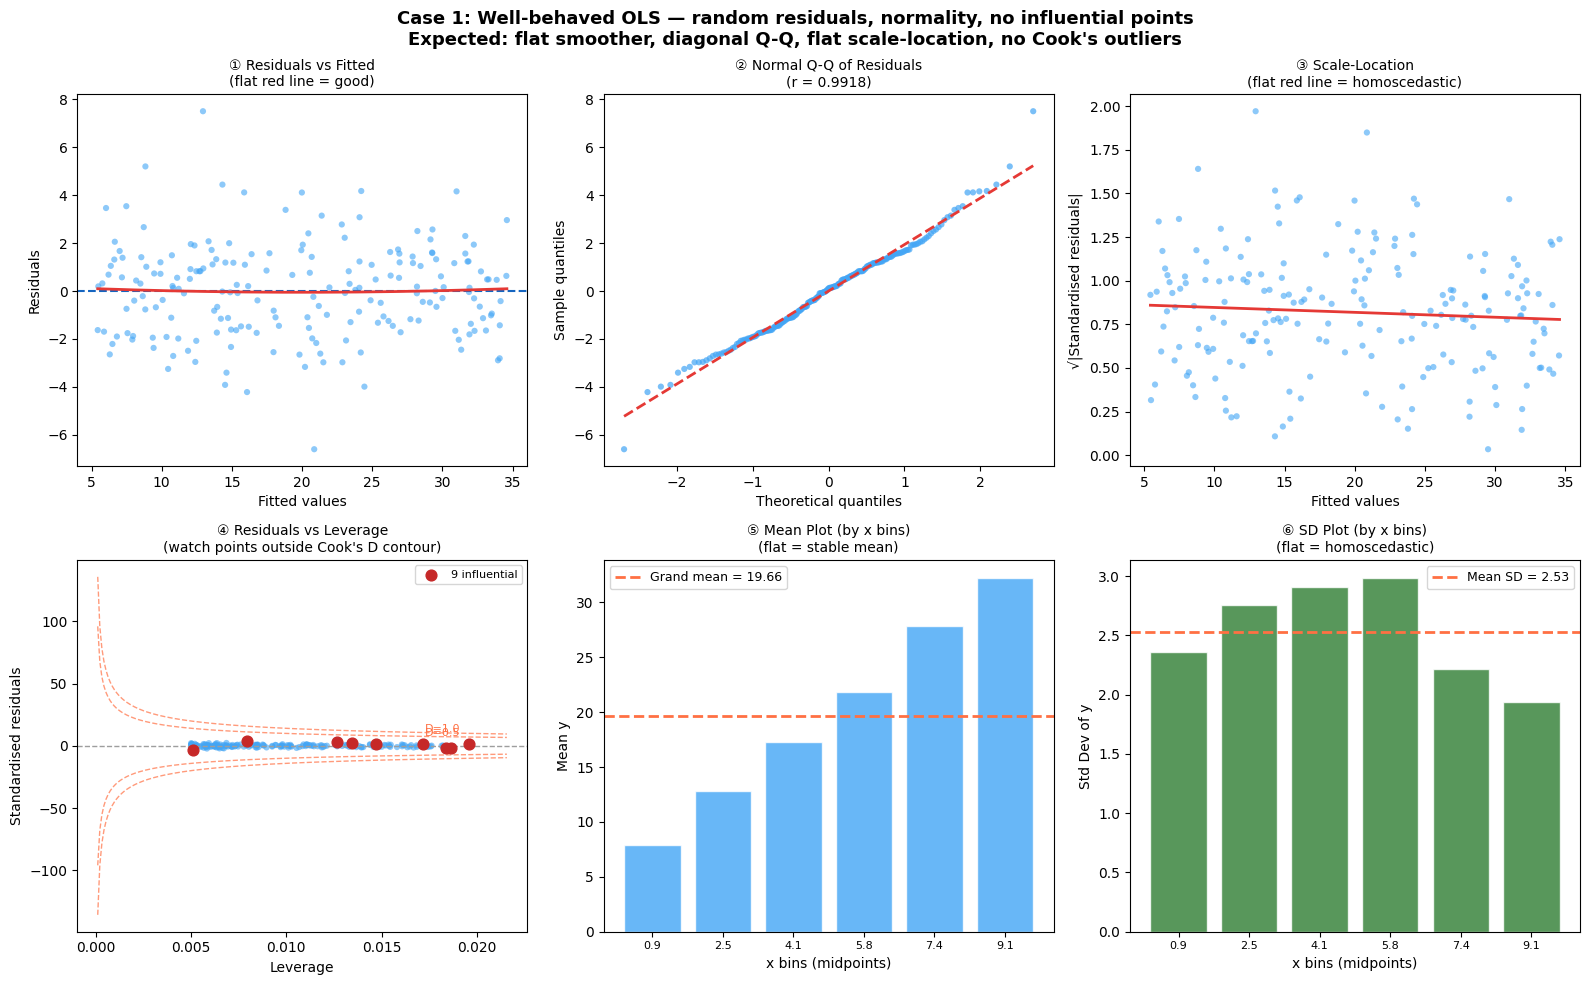


  Regression summary: y = 2.971x + 5.274
  R² = 0.9534  |  p-value = 7.8510e-134
  Influential points (Cook's D > 4/n): 9
  Q-Q correlation: 0.9918 (1.0 = perfect normality)


(np.float64(2.9712997916588604),
 np.float64(5.273739331984325),
 array([-1.63220392e+00,  1.92763338e-01,  3.17166356e-01, -1.69653438e+00,
         3.46510503e+00,  6.82946752e-01, -2.64647675e+00,  1.04995452e+00,
        -2.21140012e+00,  1.31341020e+00,  2.05678319e+00, -1.90032946e+00,
         1.66968304e+00,  5.70063901e-01,  1.38905093e+00,  3.54109760e+00,
        -7.43119374e-01, -1.75911827e+00, -2.02737066e+00, -1.87944655e+00,
        -4.01222062e-01,  4.36596718e-01,  3.10607331e-01,  1.41221230e+00,
        -2.15168411e-01,  2.66658348e+00, -7.68729201e-01,  5.20100061e+00,
         1.01262059e+00, -1.94858565e+00, -2.37548930e+00,  7.31651045e-01,
        -6.79079772e-01,  1.19903241e+00,  7.17513592e-01, -3.73126312e-01,
        -1.91838599e+00, -3.25339025e+00, -1.11458509e+00,  1.49169573e+00,
         2.07501770e-01, -2.71168569e+00,  1.26168515e-01,  5.53142917e-01,
        -1.98442239e+00,  9.10176714e-02, -9.63801279e-02, -2.49593452e+00,
         5.06840148e-01

In [4]:
np.random.seed(42)
n = 200
x = np.sort(np.random.uniform(0, 10, n))

# Case 1: Well-behaved (IID normal residuals, homoscedastic)
y_good = 3.0 * x + 5.0 + np.random.normal(0, 2, n)
regression_diagnostics(x, y_good,
    title="Case 1: Well-behaved OLS — random residuals, normality, no influential points\nExpected: flat smoother, diagonal Q-Q, flat scale-location, no Cook's outliers")

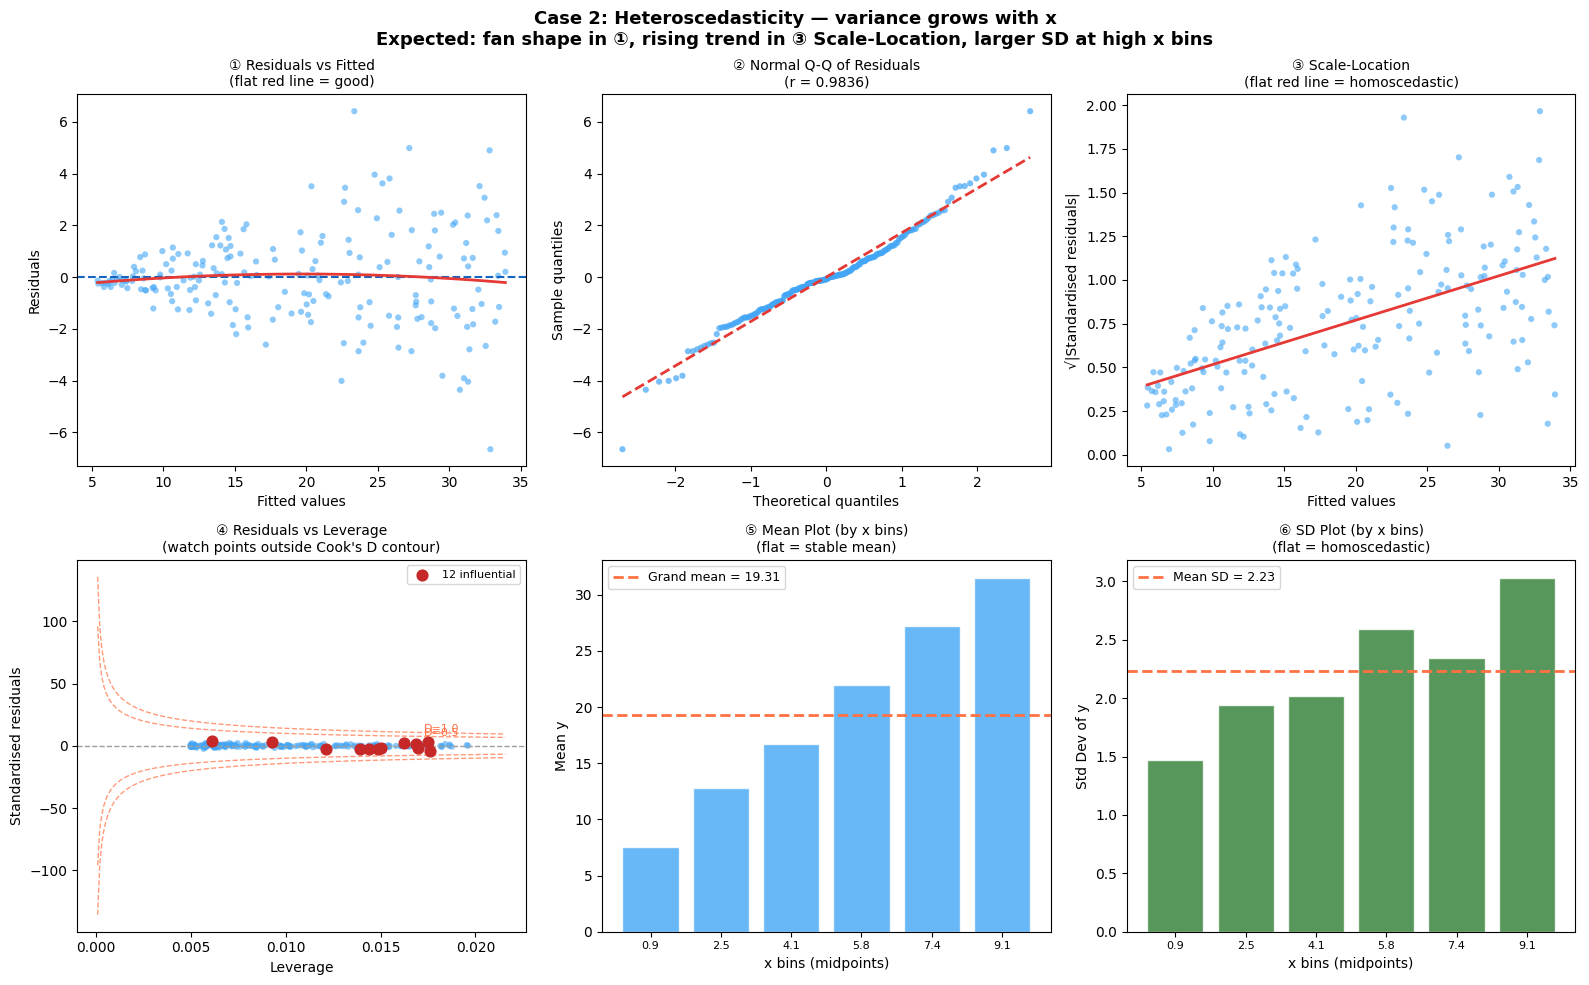


  Regression summary: y = 2.906x + 5.242
  R² = 0.9610  |  p-value = 1.8893e-141
  Influential points (Cook's D > 4/n): 12
  Q-Q correlation: 0.9836 (1.0 = perfect normality)


(np.float64(2.906438615619566),
 np.float64(5.241865392372302),
 array([-1.36724570e-01, -2.54690476e-01, -2.29193524e-01, -3.84768871e-01,
        -2.21345982e-01, -2.68542593e-01, -1.44125718e-01, -3.81618621e-01,
        -8.82516711e-02,  1.61688653e-01, -2.24437619e-01, -9.14911344e-02,
         1.75100631e-03, -2.99024101e-01, -1.14860254e-01, -1.68531751e-01,
        -1.40501720e-01, -4.25661572e-01, -1.50112665e-01,  2.73032492e-02,
         3.95673666e-01,  2.26527101e-01,  7.71327350e-01, -4.68978273e-01,
         2.48489952e-01, -5.13914983e-02,  8.74672425e-01, -5.01208437e-01,
        -5.19091429e-01, -4.20425285e-01, -1.21255382e+00, -3.84865096e-01,
        -5.12196300e-01, -1.04935612e-02,  9.82443132e-02,  1.00402859e+00,
         4.98932299e-01, -4.38194004e-01, -6.51651558e-01,  2.49582907e-01,
        -9.33089297e-01,  1.14059267e+00,  7.10780788e-01, -3.81269840e-01,
        -1.24853779e+00,  8.91337852e-01, -1.27615832e-01,  9.14509394e-01,
        -1.27278896e+00,

In [5]:
# Case 2: Heteroscedastic — residual variance grows with x
y_hetero = 3.0 * x + 5.0 + np.random.normal(0, 0.3 * x + 0.1, n)
regression_diagnostics(x, y_hetero,
    title="Case 2: Heteroscedasticity — variance grows with x\nExpected: fan shape in ①, rising trend in ③ Scale-Location, larger SD at high x bins")

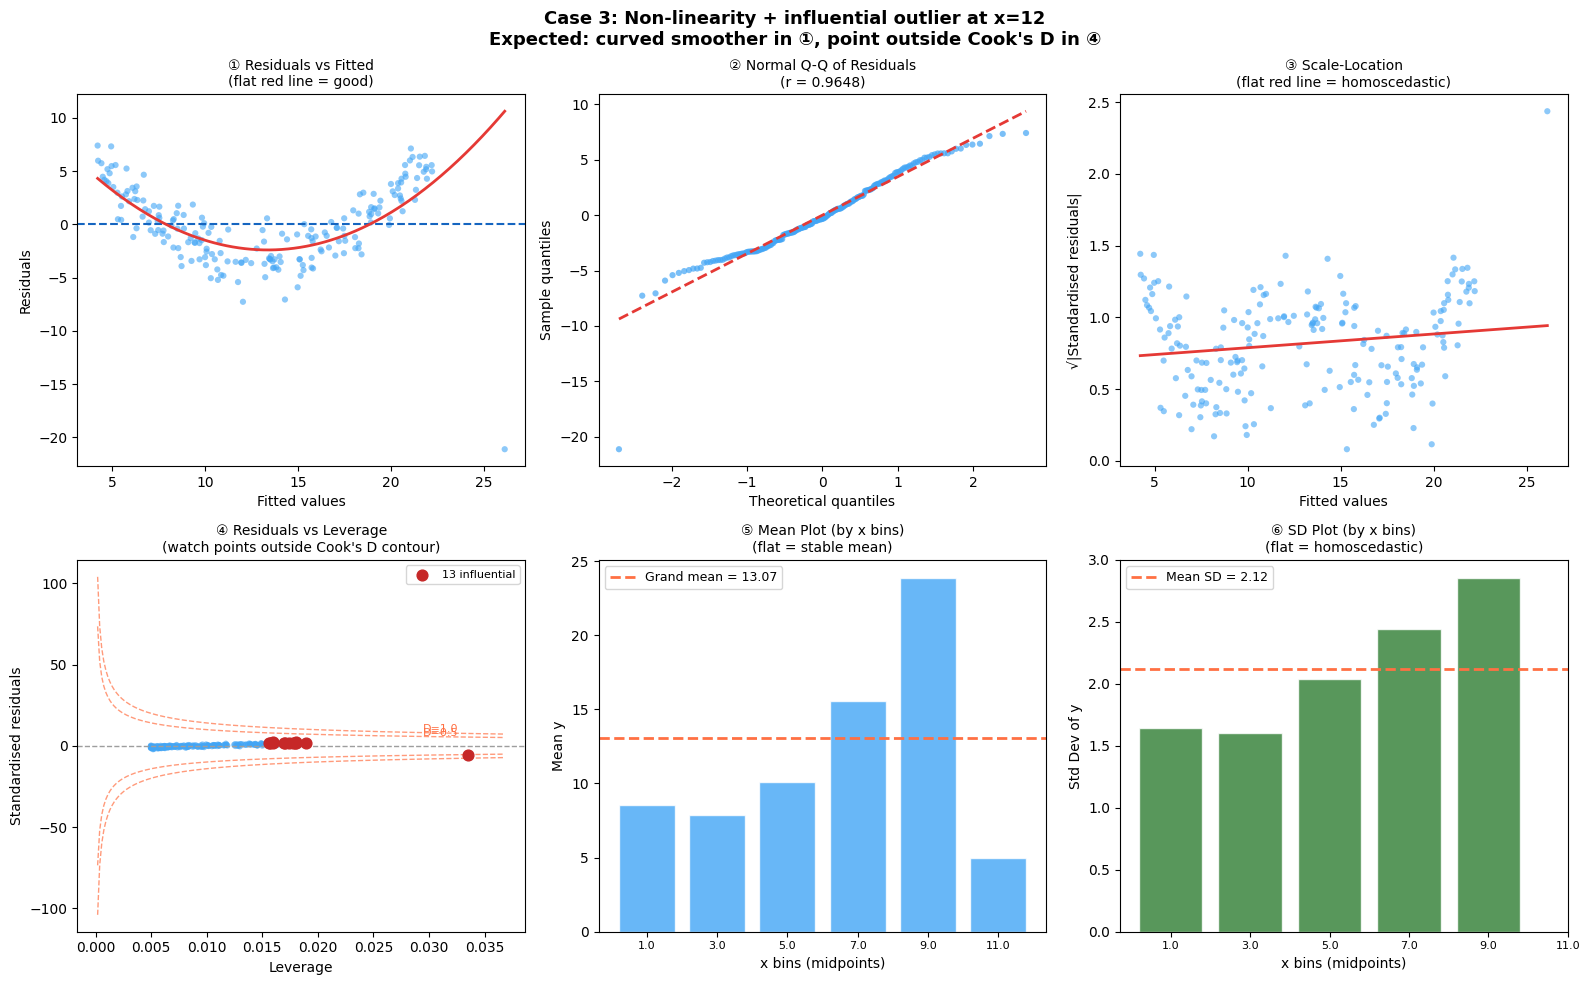


  Regression summary: y = 1.832x + 4.132
  R² = 0.7019  |  p-value = 3.3736e-54
  Influential points (Cook's D > 4/n): 13
  Q-Q correlation: 0.9648 (1.0 = perfect normality)


(np.float64(1.8321661047331608),
 np.float64(4.132191072991139),
 array([  7.40908507,   5.98495629,   5.74954601,   4.47811032,
          4.18814171,   4.05406479,   5.18896471,   3.87718899,
          4.80640455,   7.3295456 ,   5.48074464,   3.51202485,
          5.57871755,   2.98162087,   0.48700542,   1.73746983,
          0.42702849,   2.62757695,   2.81749374,   5.24850063,
          3.13707229,   2.17779416,   3.442961  ,  -1.18180954,
          2.38778655,   3.12083745,  -0.36100925,   3.56470826,
          2.2945789 ,   0.73132645,   2.24968677,   4.66778332,
          1.42777709,   1.23554229,   0.17354677,  -0.54553301,
          1.74168405,  -0.88218194,   0.32973627,  -0.53155413,
          0.86919567,   0.61216914,   1.66677976,  -0.8712332 ,
         -0.57260158,  -1.65738288,  -1.13230247,  -0.10450538,
          0.37561097,  -2.17211557,   0.49823608,   1.05346439,
         -0.39685231,   1.75452235,  -2.22520476,  -3.06660081,
         -3.91321427,   0.8884791 ,  -0

In [6]:
# Case 3: Non-linearity + one influential outlier
y_nonlin = 2.0 * x + 0.4 * (x - 5)**2 + np.random.normal(0, 1.5, n)
# Inject one extreme outlier with high leverage
x_infl = np.append(x, 12.0)
y_infl = np.append(y_nonlin, 5.0)  # far from the trend

regression_diagnostics(x_infl, y_infl,
    title="Case 3: Non-linearity + influential outlier at x=12\nExpected: curved smoother in ①, point outside Cook's D in ④")

## Key Takeaways

| | |
|---|---|
| **Purpose** | Diagnose whether OLS assumptions hold: linearity, homoscedasticity, normality, no influential points |
| **① Residuals vs Fitted** | Primary check — any pattern (curve, fan, trend) is a problem; must look random |
| **② Normal Q-Q** | Heavy tails (S-curve) → use robust regression or transform; test with Shapiro-Wilk |
| **③ Scale-Location** | Upward trend → heteroscedasticity → use WLS, robust SE, or transform y |
| **④ Residuals vs Leverage** | Points beyond Cook's D contour → investigate; consider removing only with justification |
| **⑤ Mean Plot** | Checks if mean is constant across x range (supports linearity assumption) |
| **⑥ SD Plot** | Checks if variance is constant across x range (supports homoscedasticity) |
| **Cook's distance** | Combines residual size AND leverage — a point needs both to be truly influential |
| **Leverage alone** | High leverage ≠ harmful if it follows the regression line (low residual) |
| **Remedies** | Non-linearity → add polynomial/transform; heteroscedasticity → WLS or log(y); outliers → robust regression |
| **Order of priority** | Fix linearity first (① smoother), then check variance (③), then normality (②) |